# TVB/?TVB ???????????

?? notebook ??????? forward ????????????????????

1. ?????`tvboptim + optax`?
2. ?????`scipy.differential_evolution`?
3. ?????????`sbi`?

?????

- ????wall-clock?
- ???????simulation calls?
- ??????`G`?
- ???????FC RMSE?
- ???????FC correlation?

> ?????????????????? FC ???????????

In [8]:
# ????????????????????
# %pip install -U numpy pandas matplotlib seaborn scipy torch sbi jax jaxlib tvboptim


In [9]:
import time
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_context('notebook')
sns.set_style('whitegrid')


In [10]:
# ====== ?????tvboptim (forward model) ======
import jax
import jax.numpy as jnp

from tvboptim.experimental.network_dynamics import Network, solve, prepare
from tvboptim.experimental.network_dynamics.dynamics.tvb import ReducedWongWang
from tvboptim.experimental.network_dynamics.coupling import DelayedLinearCoupling
from tvboptim.experimental.network_dynamics.graph import DenseDelayGraph
from tvboptim.experimental.network_dynamics.noise import AdditiveNoise
from tvboptim.experimental.network_dynamics.solvers import Heun, BoundedSolver
from tvboptim.observations.tvb_monitors import Bold, SubSampling
from tvboptim.observations import compute_fc, fc_corr, rmse
from tvboptim.data import load_structural_connectivity, load_functional_connectivity
from tvboptim.types import Parameter
from tvboptim.optim import OptaxOptimizer

import optax


In [11]:
# ====== ???? ======
G_MIN, G_MAX = 0.0, 2.5
G_INIT = 0.5

SIM_T0 = 0.0
SIM_T1 = 60_000.0   # ms
SIM_DT = 1.0

# ??1????
GRAD_STEPS = 50
GRAD_LR = 0.03

# ??2????
DE_MAXITER = 18
DE_POPSIZE = 8
DE_POLISH = False

# ??3?SBI
SBI_NUM_SIM = 220
SBI_POST_SAMPLES = 2000

# ???????
# True  -> ????????(???G????????)
# False -> ?????FC?(???G????????)
USE_SYNTHETIC_TARGET = True
G_TRUE_SYNTH = 1.2


In [12]:
# ====== Build unified forward model and target FC ======
weights, lengths, labels = load_structural_connectivity('dk_average')
weights = weights / jnp.max(weights)
delays = lengths / 3.0

network = Network(
    dynamics=ReducedWongWang(),
    coupling={'delayed': DelayedLinearCoupling(incoming_states='S', G=G_INIT)},
    graph=DenseDelayGraph(weights, delays, region_labels=labels),
    noise=AdditiveNoise(sigma=0.01, key=jax.random.key(42)),
)

solver = BoundedSolver(Heun(), low=0.0, high=1.0)
warmup = solve(network, solver, t0=SIM_T0, t1=SIM_T1, dt=SIM_DT)
network.update_history(warmup)

simulator, base_params = prepare(network, solver, t0=SIM_T0, t1=SIM_T1, dt=SIM_DT)
bold_monitor = Bold(history=warmup, period=720.0, downsample=SubSampling(period=4.0))

# Empirical FC
target_fc_empirical = np.asarray(load_functional_connectivity('dk_average'))

# IMPORTANT:
# - Keep JAX arrays in gradient path
# - Convert to NumPy only in non-gradient paths
def fc_from_params_jax(params):
    sol = simulator(params)
    bold = bold_monitor(sol)
    return compute_fc(bold)

def fc_from_params_np(params):
    return np.asarray(fc_from_params_jax(params))

def fc_from_g(g_value):
    p = copy.deepcopy(base_params)
    p.coupling.delayed.G = float(g_value)
    return fc_from_params_np(p)

if USE_SYNTHETIC_TARGET:
    target_fc = fc_from_g(G_TRUE_SYNTH)
    target_name = f'synthetic(G_true={G_TRUE_SYNTH})'
else:
    target_fc = target_fc_empirical
    target_name = 'empirical(dk_average)'

target_fc_jax = jnp.asarray(target_fc)

print('Target mode:', target_name)
print('FC shape:', target_fc.shape)


Target mode: synthetic(G_true=1.2)
FC shape: (84, 84)


In [13]:
# ====== Unified metrics ======
def fc_upper_triangle(fc):
    iu = np.triu_indices(fc.shape[0], k=1)
    return fc[iu]

def fc_feature_vector(fc):
    # low-dimensional summary for SBI
    v = fc_upper_triangle(fc)
    eigvals = np.linalg.eigvalsh(fc)
    eigvals = np.sort(eigvals)[::-1]
    top3 = eigvals[:3]
    feats = np.array([
        np.mean(v),
        np.std(v),
        np.percentile(v, 10),
        np.percentile(v, 50),
        np.percentile(v, 90),
        *top3,
    ], dtype=np.float32)
    return feats

TARGET_FEATURE = fc_feature_vector(target_fc)

def objective_rmse(fc_pred):
    return float(rmse(jnp.asarray(fc_pred), target_fc_jax))

def objective_corr(fc_pred):
    return float(fc_corr(jnp.asarray(fc_pred), target_fc_jax))


## ??1??????Optax Adam?

In [14]:
sim_calls_grad = 0

def run_gradient_method():
    global sim_calls_grad
    sim_calls_grad = 0

    p0 = copy.deepcopy(base_params)
    p0.coupling.delayed.G = Parameter(float(G_INIT))

    def loss(params):
        # Pure JAX path: do NOT convert to NumPy here
        pred = fc_from_params_jax(params)
        return rmse(pred, target_fc_jax)

    opt = OptaxOptimizer(loss, optax.adam(learning_rate=GRAD_LR))

    t0 = time.perf_counter()
    p_final, hist = opt.run(p0, max_steps=GRAD_STEPS)
    wall = time.perf_counter() - t0

    # Python side-effect counting is unreliable under jit;
    # use configured step count as stable estimate.
    sim_calls_grad = int(GRAD_STEPS)

    g_final = np.asarray(p_final.coupling.delayed.G.value).item()
    fc_final = fc_from_params_np(p_final)

    return {
        'method': 'Gradient(Optax)',
        'g': g_final,
        'wall_s': wall,
        'sim_calls': int(sim_calls_grad),
        'rmse': objective_rmse(fc_final),
        'corr': objective_corr(fc_final),
        'fc': fc_final,
        'history': hist,
    }

res_grad = run_gradient_method()
print({k: v for k, v in res_grad.items() if k not in ['fc', 'history']})


{'method': 'Gradient(Optax)', 'g': -0.05598454549908638, 'wall_s': 182.84231686200656, 'sim_calls': 50, 'rmse': 0.25076746940612793, 'corr': 0.7042565941810608}


## ??2??????Differential Evolution?

In [15]:
from scipy.optimize import differential_evolution

sim_calls_de = 0

def run_evolution_method():
    global sim_calls_de
    sim_calls_de = 0

    def f(x):
        global sim_calls_de
        sim_calls_de += 1
        g = float(x[0])
        fc_pred = fc_from_g(g)
        return objective_rmse(fc_pred)

    t0 = time.perf_counter()
    result = differential_evolution(
        f,
        bounds=[(G_MIN, G_MAX)],
        strategy='best1bin',
        maxiter=DE_MAXITER,
        popsize=DE_POPSIZE,
        tol=1e-4,
        polish=DE_POLISH,
        seed=42,
    )
    wall = time.perf_counter() - t0

    g_final = float(result.x[0])
    fc_final = fc_from_g(g_final)

    return {
        'method': 'Evolution(DE)',
        'g': g_final,
        'wall_s': wall,
        'sim_calls': int(sim_calls_de),
        'rmse': objective_rmse(fc_final),
        'corr': objective_corr(fc_final),
        'fc': fc_final,
        'history': result,
    }

res_de = run_evolution_method()
print({k: v for k, v in res_de.items() if k not in ['fc', 'history']})


{'method': 'Evolution(DE)', 'g': 1.2000012793127928, 'wall_s': 188.10349982698972, 'sim_calls': 152, 'rmse': 7.69232542552345e-07, 'corr': 1.0}


## ??3?SBI?SNPE?

In [16]:
import torch
from sbi.utils import BoxUniform
from sbi.inference import SNPE

def run_sbi_method():
    prior = BoxUniform(
        low=torch.tensor([G_MIN], dtype=torch.float32),
        high=torch.tensor([G_MAX], dtype=torch.float32),
    )

    # 1) ?????
    t0 = time.perf_counter()
    theta = prior.sample((SBI_NUM_SIM,))

    xs = []
    for i in range(SBI_NUM_SIM):
        g = float(theta[i, 0].item())
        fc_pred = fc_from_g(g)
        xs.append(fc_feature_vector(fc_pred))
    x = torch.tensor(np.stack(xs), dtype=torch.float32)

    # 2) ????
    inference = SNPE(prior=prior)
    density_estimator = inference.append_simulations(theta, x).train()
    posterior = inference.build_posterior(density_estimator)

    # 3) ???? + ???????????
    x_obs = torch.tensor(TARGET_FEATURE, dtype=torch.float32)
    post_samples = posterior.sample((SBI_POST_SAMPLES,), x=x_obs)

    g_mean = float(post_samples[:, 0].mean().item())
    g_std = float(post_samples[:, 0].std().item())

    wall = time.perf_counter() - t0

    fc_final = fc_from_g(g_mean)

    return {
        'method': 'SBI(SNPE)',
        'g': g_mean,
        'g_std': g_std,
        'wall_s': wall,
        'sim_calls': int(SBI_NUM_SIM),
        'rmse': objective_rmse(fc_final),
        'corr': objective_corr(fc_final),
        'fc': fc_final,
        'posterior_samples': post_samples.numpy(),
    }

res_sbi = run_sbi_method()
print({k: v for k, v in res_sbi.items() if k not in ['fc', 'posterior_samples']})


 Neural network successfully converged after 530 epochs.

  0%|          | 0/2000 [00:00<?, ?it/s]

{'method': 'SBI(SNPE)', 'g': 1.200699806213379, 'g_std': 0.007576477713882923, 'wall_s': 718.8470452030015, 'sim_calls': 220, 'rmse': 0.0003065103373955935, 'corr': 0.9999998807907104}


## ??????? / ?? / ?? / ???

In [17]:
results = [res_grad, res_de, res_sbi]

df = pd.DataFrame([
    {
        'method': r['method'],
        'G_final': r['g'],
        'wall_time_s': r['wall_s'],
        'sim_calls': r['sim_calls'],
        'FC_RMSE': r['rmse'],
        'FC_corr': r['corr'],
        'G_posterior_std': r.get('g_std', np.nan),
        'G_abs_error': (abs(r['g'] - G_TRUE_SYNTH) if USE_SYNTHETIC_TARGET else np.nan),
    }
    for r in results
])

df = df.sort_values('FC_RMSE').reset_index(drop=True)
display(df)


,method,G_final,wall_time_s,sim_calls,FC_RMSE,FC_corr,G_posterior_std,G_abs_error
0,Evolution(DE),1.200001,188.103500,152,7.692325e-07,1.000000,NaN,0.000001
1,SBI(SNPE),1.200700,718.847045,220,3.065103e-04,1.000000,0.007576,0.000700
2,Gradient(Optax),-0.055985,182.842317,50,2.507675e-01,0.704257,NaN,1.255985


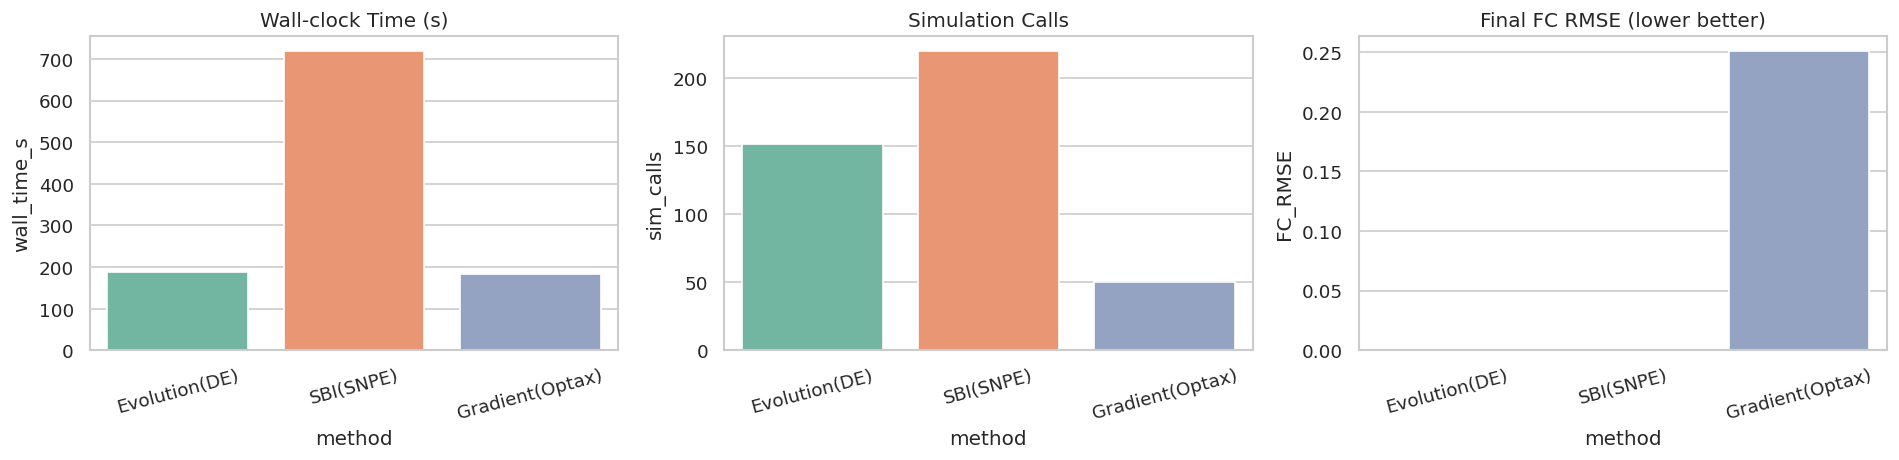

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=120)

sns.barplot(data=df, x='method', y='wall_time_s', ax=axes[0], palette='Set2')
axes[0].set_title('Wall-clock Time (s)')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=df, x='method', y='sim_calls', ax=axes[1], palette='Set2')
axes[1].set_title('Simulation Calls')
axes[1].tick_params(axis='x', rotation=15)

sns.barplot(data=df, x='method', y='FC_RMSE', ax=axes[2], palette='Set2')
axes[2].set_title('Final FC RMSE (lower better)')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


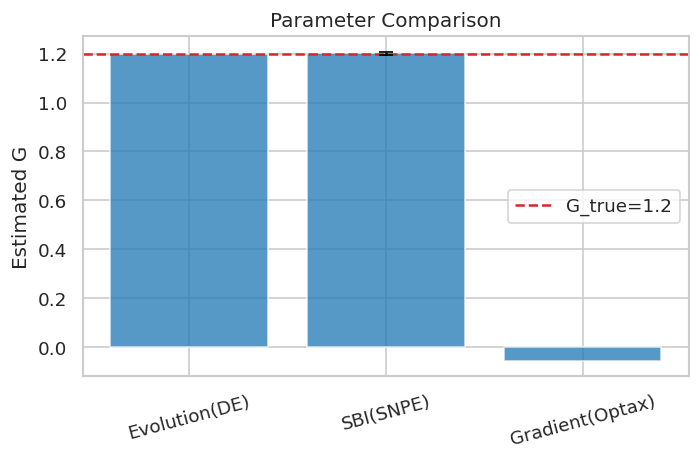

In [19]:
# ???????
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=120)

x = np.arange(len(df))
ax.bar(x, df['G_final'], color='tab:blue', alpha=0.75)
ax.set_xticks(x)
ax.set_xticklabels(df['method'], rotation=15)
ax.set_ylabel('Estimated G')
ax.set_title('Parameter Comparison')

if USE_SYNTHETIC_TARGET:
    ax.axhline(G_TRUE_SYNTH, color='tab:red', linestyle='--', label=f'G_true={G_TRUE_SYNTH}')

for i, (_, row) in enumerate(df.iterrows()):
    if not np.isnan(row['G_posterior_std']):
        ax.errorbar(i, row['G_final'], yerr=row['G_posterior_std'], color='k', capsize=4)

if USE_SYNTHETIC_TARGET:
    ax.legend()

plt.tight_layout()
plt.show()


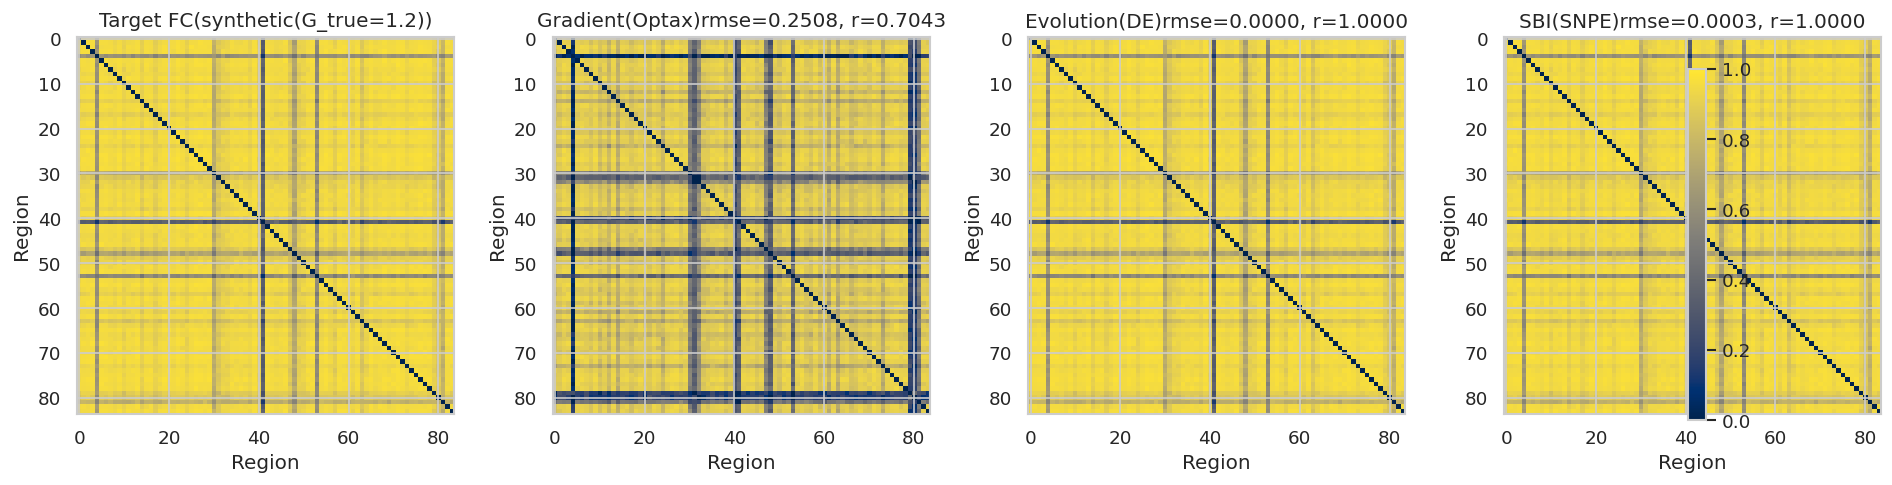

In [20]:
# FC????
fc_target = target_fc

name_to_fc = {r['method']: r['fc'] for r in results}
methods = list(name_to_fc.keys())

n = len(methods) + 1
fig, axes = plt.subplots(1, n, figsize=(4*n, 3.8), dpi=120)

im0 = axes[0].imshow(fc_target, cmap='cividis', vmin=0, vmax=1)
axes[0].set_title(f'Target FC({target_name})')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Region')

for i, m in enumerate(methods, start=1):
    fc_i = name_to_fc[m]
    corr_i = objective_corr(fc_i)
    rmse_i = objective_rmse(fc_i)
    axes[i].imshow(fc_i, cmap='cividis', vmin=0, vmax=1)
    axes[i].set_title(f'{m}rmse={rmse_i:.4f}, r={corr_i:.4f}')
    axes[i].set_xlabel('Region')
    axes[i].set_ylabel('Region')

fig.colorbar(im0, ax=axes.ravel().tolist(), fraction=0.015)
plt.tight_layout()
plt.show()


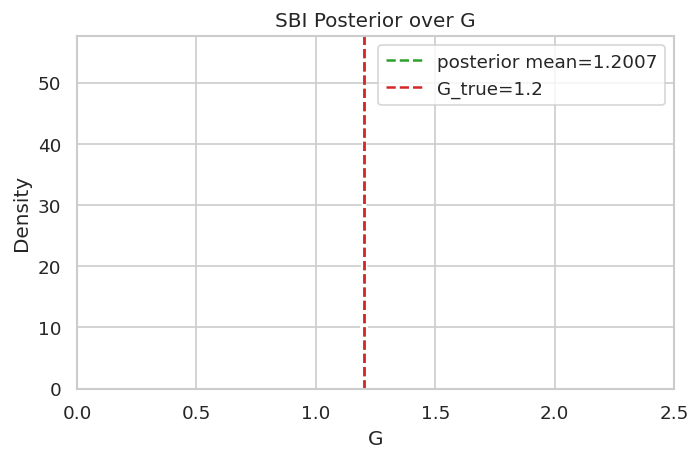

In [21]:
# SBI??????SBI?
samples = res_sbi['posterior_samples'][:, 0]

plt.figure(figsize=(6, 4), dpi=120)
sns.histplot(samples, bins=40, stat='density', color='tab:green', alpha=0.5)
plt.axvline(res_sbi['g'], color='tab:green', linestyle='--', label=f'posterior mean={res_sbi["g"]:.4f}')
if USE_SYNTHETIC_TARGET:
    plt.axvline(G_TRUE_SYNTH, color='tab:red', linestyle='--', label=f'G_true={G_TRUE_SYNTH}')
plt.xlim(G_MIN, G_MAX)
plt.xlabel('G')
plt.ylabel('Density')
plt.title('SBI Posterior over G')
plt.legend()
plt.tight_layout()
plt.show()


## ??????

- ????????? `G` ????????????????????????
- ?????????????? `G`, `sigma`, `tau`?????
  - ???????
  - ?? `fc_from_g` ? `fc_from_theta`?
  - ?????SBI??????????
- ????????????????????????????????